In [2]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.cluster import DBSCAN
import scipy

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

In [3]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
file = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
os.path.join(dir, file) 

'/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi'

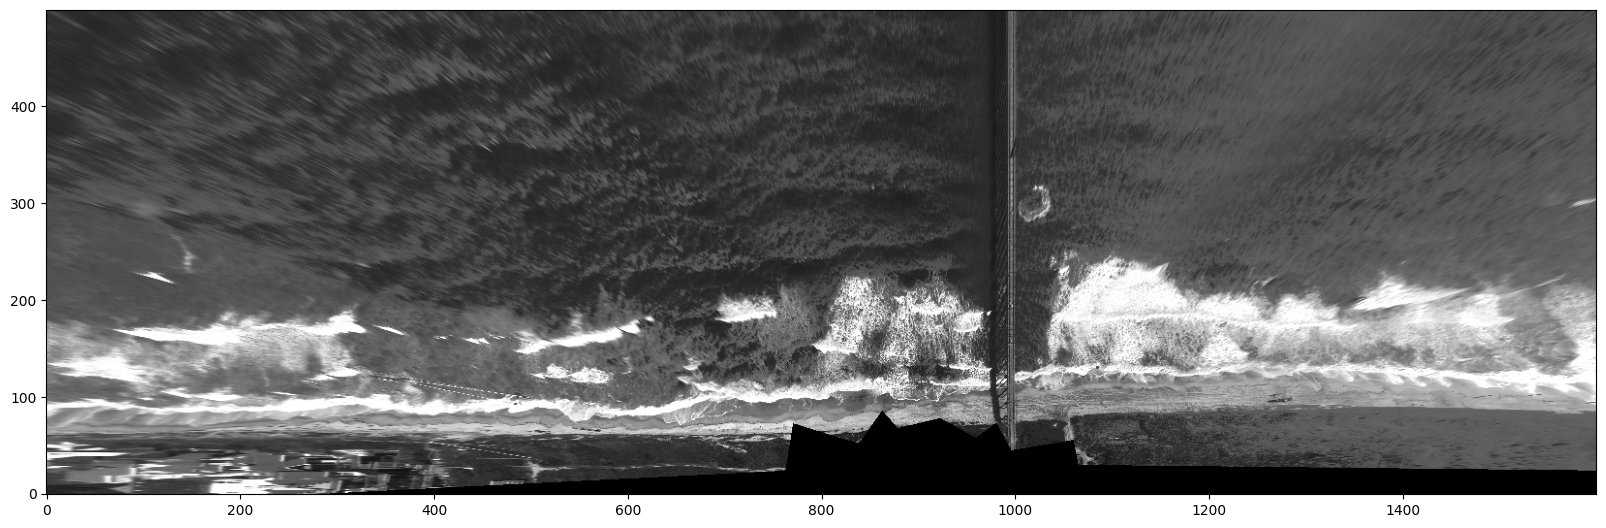

In [4]:
cap = cv2.VideoCapture(os.path.join(dir, file))
_, frame = cap.read()
frame = frame[..., 0]
plt.figure(figsize=(20, 30))
plt.imshow(frame.T)
cap.release()
cv2.destroyAllWindows()

In [5]:
i = 150
t = timestack[:, 0, :].T
fig, axs = plt.subplots(2, 1, figsize=(30, 10), sharex=True)
axs[0].set_title(f'Timestack {i*10}m')
axs[0].imshow(t)
axs[0].set_ylabel('Cross Shore [m]')
# plt.imshow((timestack == 0).T, cmap='jet', alpha=0.75)
im = axs[1].imshow((np.zeros_like(t) + np.all((t==0), axis=0)[:, np.newaxis].T))
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Cross Shore [m]')
plt.title('Missing Data')
# ax = axs[1]
# cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
# plt.colorbar(im, cax=cax, ticks=[0, 1])

NameError: name 'timestack' is not defined

In [41]:
cap = cv2.VideoCapture(os.path.join(dir, file))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# NOTE: We're downsampling in along-shore to 10m
skip = 1
timestack = np.zeros((N, H//skip, W))
stop = 300
# stop = np.inf

for i in tqdm(range(min(N, stop))):
    _, frame = cap.read()
    timestack[i] = frame[::skip, :, 0]

cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


100%|██████████| 300/300 [00:00<00:00, 629.52it/s]


(array([[  0.,   0.,   0., ...,   0.,   0., 500.],
        [  0.,   0.,   0., ...,   0.,   0., 500.],
        [  0.,   0.,   0., ...,   0.,   0., 500.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0., 500.],
        [  0.,   0.,   0., ...,   0.,   0., 500.],
        [  0.,   0.,   0., ...,   0.,   0., 500.]]),
 array([-5.        , -4.22850471, -3.45700943, -2.68551414, -1.91401885,
        -1.14252356, -0.37102828,  0.40046701,  1.1719623 ,  1.94345758,
         2.71495287]),
 <a list of 3840 BarContainer objects>)

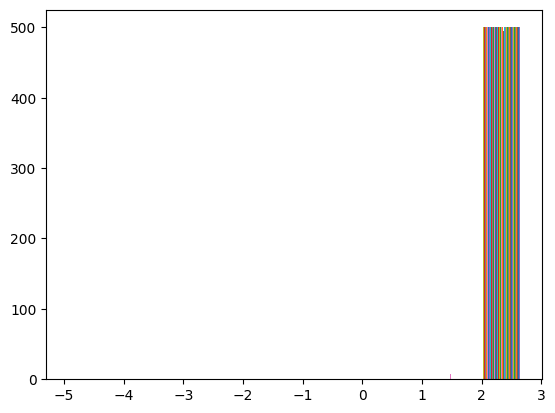

In [ ]:
x = np.log10(normalize(t - uniform_filter1d(uniform_filter1d(t, N, axis=0),NFRAMES, axis=1)).T + 1e-5)
plt.hist(x)

In [42]:
x = normalize(t - uniform_filter1d(t, t.shape[0], axis=0))
plt.hist(x)

NameError: name 'normalize' is not defined

In [43]:
from scipy.ndimage import uniform_filter1d
t = timestack[:, 49, :]
# t[t==0] = np.nan
NFRAMES = 
fig, axs = plt.subplots(1, 4, sharey=True, figsize=(30, 10))
axs[0].imshow(t.T, vmin=0, vmax=255)
axs[1].imshow(normalize(t - uniform_filter1d(t, t.shape[0], axis=0)).T, vmin=0, vmax=255)
axs[1].set_title('Minus Rolling Average')
axs[2].imshow((normalize(t - uniform_filter1d(t, NFRAMES, axis=1)).T))
axs[2].set_title('Minus Timex')
axs[3].imshow(normalize(t - uniform_filter1d(uniform_filter1d(t, N, axis=0), NFRAMES, axis=1)).T)
axs[3].set_title('Minus Rolling Average - Timex')
axs[0].set_xlim([0, 300])
axs[1].set_xlim([0, 300])
axs[2].set_xlim([0, 300])
axs[3].set_xlim([0, 300])


SyntaxError: invalid syntax (900848184.py, line 4)

In [44]:
from scipy.ndimage import binary_erosion, binary_dilation, binary_closing
plt.figure(figsize=(20, 10))
plt.imshow(normalize(t - uniform_filter1d(t, t.shape[0], axis=0)).T, vmin=0, vmax=255)
plt.imshow(binary_dilation(binary_dilation(binary_dilation(
           binary_erosion(binary_erosion(
               normalize(t - uniform_filter1d(t, t.shape[0], axis=0)).T > 150
            ))
))), cmap='jet', alpha=0.5)
plt.colorbar()
plt.xlim([0, 300])


NameError: name 'normalize' is not defined

<Figure size 2000x1000 with 0 Axes>

In [45]:
def numpy_ewma_vectorized_v2(data, window):

    alpha = 2 /(window + 1.0)
    alpha_rev = 1-alpha
    n = data.shape[0]

    pows = alpha_rev**(np.arange(n+1))

    scale_arr = 1/pows[:-1]
    offset = data[0]*pows[1:]
    pw0 = alpha*alpha_rev**(n-1)

    mult = data*pw0*scale_arr
    cumsums = mult.cumsum()
    out = offset + cumsums*scale_arr[::-1]
    return out


In [46]:
plt.hist(t.T[:300 ,:])

NameError: name 't' is not defined

In [47]:
def equalize_hist(data: np.ndarray, rate: float=0.05) -> np.ndarray:
    data = cv2.equalizeHist(data.astype(np.uint8))

    hist = np.cumsum(np.histogram(data, 255)[0])
    lowest_value = np.where((rate * hist[-1]) <= hist)[0][0]
    highest_value = np.where(((1 - rate) * hist[-1]) >= hist)[0][-1]

    data[data < lowest_value] = lowest_value
    data[data > highest_value] = highest_value

    return data

plt.imshow(t[:300, :])
plt.figure()

plt.imshow(equalize_hist(t[:300, :]))
plt.figure()
plt.hist(equalize_hist(t[:300, :]))

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

plt.figure()
plt.imshow(clahe.apply(t[:300, :].astype(np.uint8)))
plt.figure()
plt.hist(clahe.apply(t[:300, :].astype(np.uint8)))

NameError: name 't' is not defined

In [48]:
foam = (
    binary_dilation(binary_dilation(binary_dilation(
           binary_erosion(
    binary_erosion(
               normalize(t - uniform_filter1d(t, t.shape[0], axis=0)).T > 150
            )))
            )
            ))

# foam = sobel(t.T)
plt.figure(figsize=(20, 20))
# plt.imshow(foam)
plt.imshow(-np.gradient(t.T)[0])
plt.plot(np.arange(3840), np.argmax(foam, axis=0), c='r')
plt.colorbar()
plt.xlim([0, 300])
plt.figure()
plt.plot(np.cumsum(t.T[:, :10], axis=1))

NameError: name 'normalize' is not defined

In [12]:
image_blurred = cv2.GaussianBlur(t.astype(np.uint8), (9,9), 0)
# - threshold
_, surf_zone = cv2.threshold(image_blurred[:250, :], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

surf_zone_floodfill = surf_zone.copy()
# - flood from top
h, w = surf_zone_floodfill.shape
mask = np.zeros((h + 2, w + 2), np.uint8)
cv2.floodFill(surf_zone_floodfill, mask, (0, 0), 255)
surf_zone_floodfill_inv = cv2.bitwise_not(surf_zone_floodfill)
surf_zone = surf_zone | surf_zone_floodfill_inv

plt.figure(figsize=(20, 15))
plt.imshow(t[:250, :].T)
plt.imshow(surf_zone_floodfill.T ,cmap='hot', alpha=0.5)
plt.xlim([0, 285])



# plt.imshow(surf_zone.T)
# plt.xlim([0, 300])


NameError: name 't' is not defined

In [13]:
roms_grid = xr.load_dataset('ocean_dunex_base_grd.nc')
roms_grid['h'].values = zgrid
roms_grid['hraw'].values = zgrid[np.newaxis, ...]
roms_grid.to_netcdf('ocean_dunex_base_smooth.nc')

NameError: name 'xr' is not defined

In [14]:
from scipy.fft import fft, fftfreq
x = np.log10(normalize(t - uniform_filter1d(uniform_filter1d(t, N, axis=0),NFRAMES, axis=1)).T + 1e-5)[250, :500]
x = x - x.mean()
N = len(x)
fs = 2
T = 1/fs
xf = fft(x)[1:]
f = fftfreq(N, T)[:N//2]
print(len(xf), len(f))
plt.plot(f[1:], 2.0/N * np.abs(xf[1:N//2]))


NameError: name 'normalize' is not defined

In [15]:
f

NameError: name 'f' is not defined

NameError: name 'timestack' is not defined

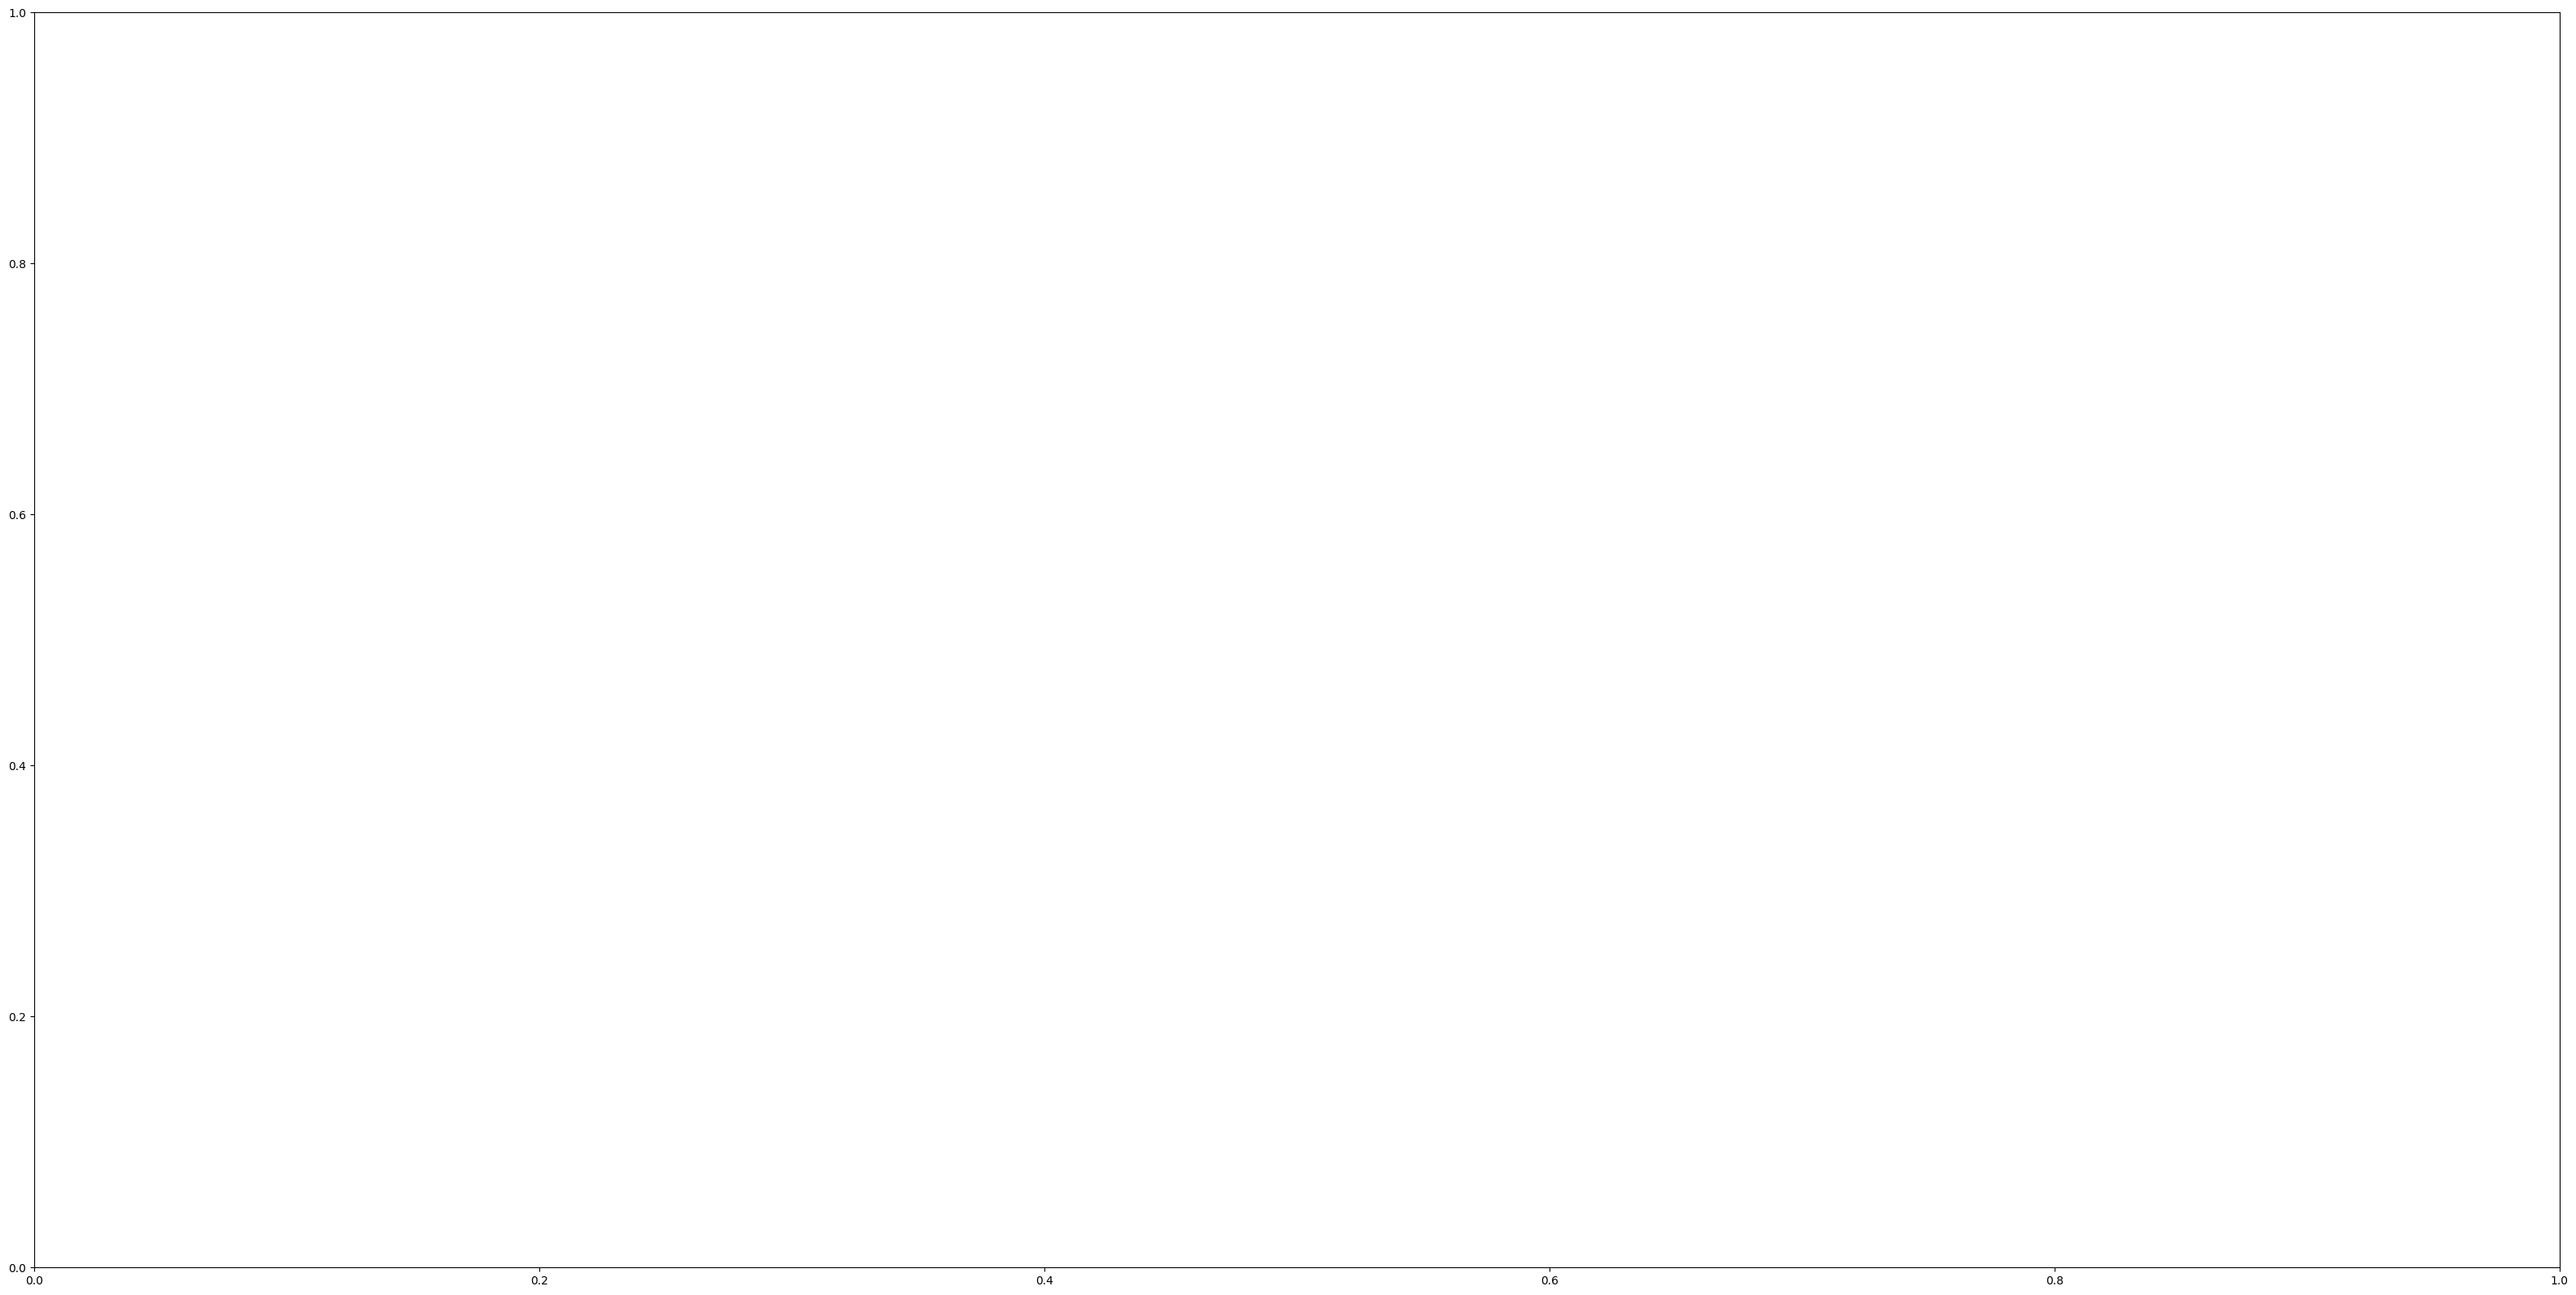

In [16]:
from scipy.ndimage import sobel
fig, axs = plt.subplots(1, 1, figsize=(40,20))

axs.imshow((timestack[:500, 50, :].T) - timestack[:500, 50, :])
# im = axs[1].imshow(sobel(timestack[:500, 50, :].T))
# fig.colorbar(im, ax=axs[1])

NameError: name 'timestack' is not defined

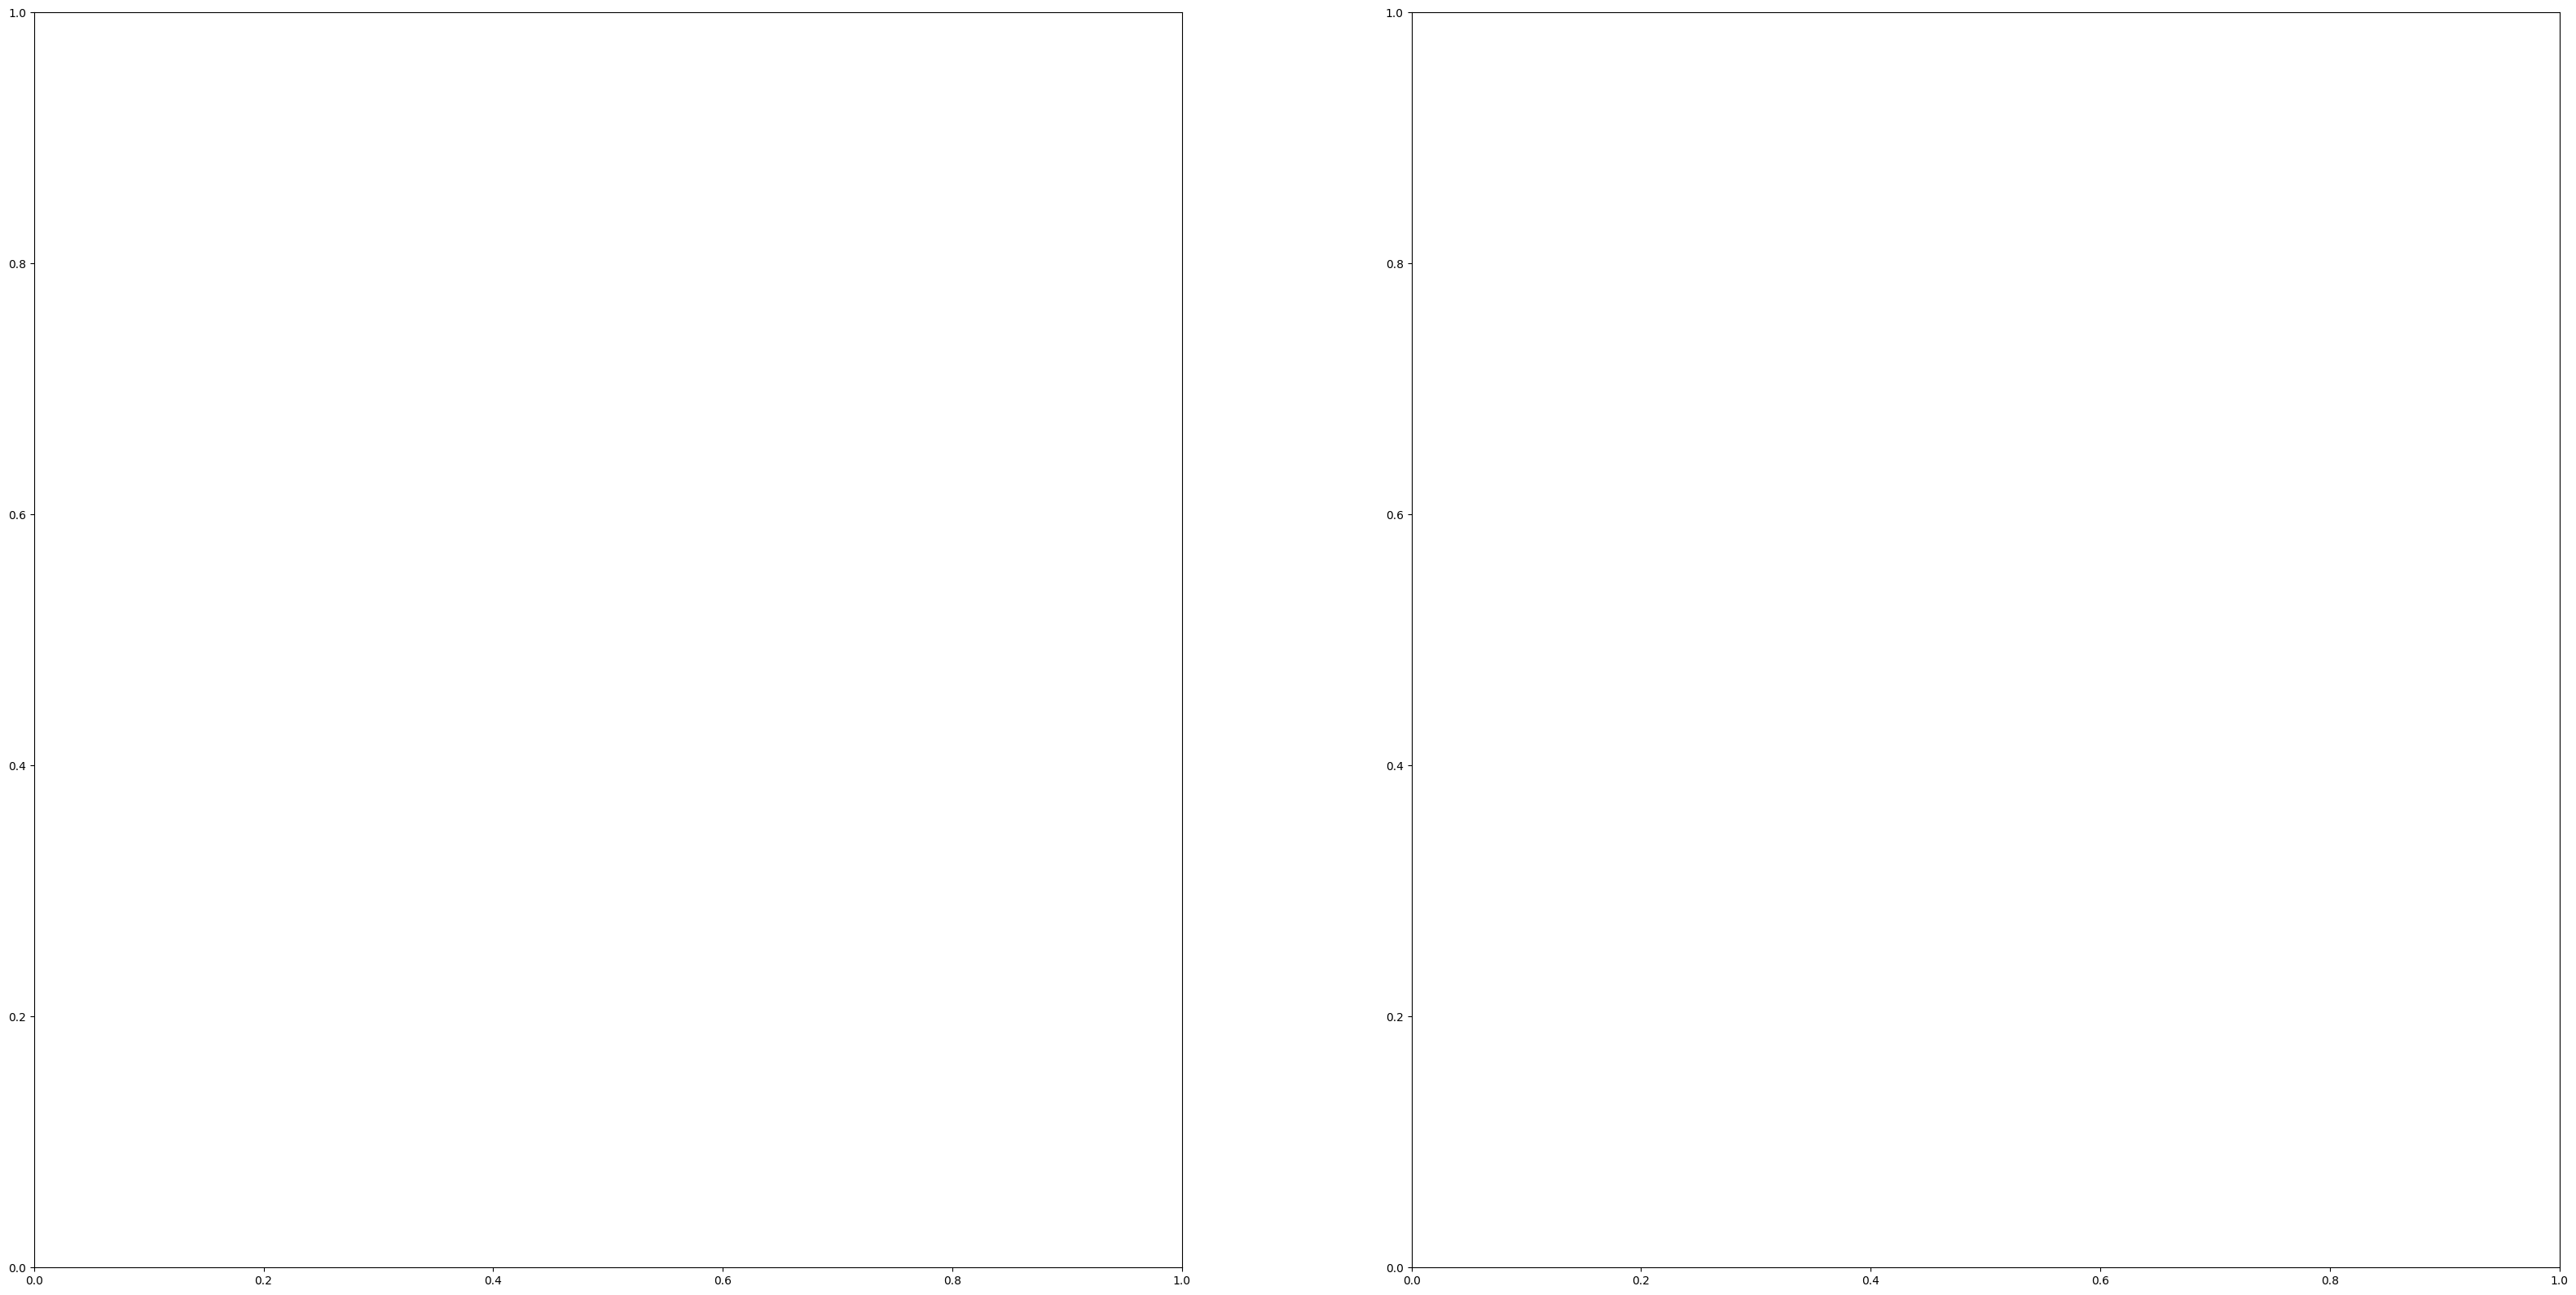

In [17]:
from scipy.ndimage import sobel
fig, axs = plt.subplots(1, 2, figsize=(40,20))
axs[0].imshow((timestack[:500, 50, :].T))
im = axs[1].imshow(sobel(timestack[:500, 50, :].T))
fig.colorbar(im, ax=axs[1])

In [18]:
import scipy
plt.plot((timestack[:200, 50, 150].T))
peaks = scipy.signal.find_peaks((timestack[:200, 50, 150].T), distance=10)[0]
plt.scatter(peaks, (timestack[:200, 50, 150].T)[peaks], c='r')

NameError: name 'timestack' is not defined

In [19]:
plt.figure(figsize=(20, 10))
plt.imshow(timestack[:200, 50, :].T)
peaks = scipy.signal.find_peaks((timestack[:200, 50, 175].T), threshold=10)[0]
plt.scatter(peaks, np.ones_like(peaks) * 150, c='r', s=5)

NameError: name 'timestack' is not defined

<Figure size 2000x1000 with 0 Axes>

In [20]:
plt.figure(figsize=(20, 10))
plt.imshow(sobel(timestack[:200, 50, :].T))
plt.scatter(np.arange(200), np.argmax(sobel(timestack[:200, 50, :].T), axis=0), c='r', s=2)

NameError: name 'timestack' is not defined

<Figure size 2000x1000 with 0 Axes>

In [49]:
peaks = []
for i in tqdm(range(0, timestack.shape[1])):
    surf_zone_min = 65
    surf_zone_max = 275
    p = np.argsort(sobel(timestack[:, i, surf_zone_min:surf_zone_max].T), axis=0)[::-1]
    peaks.append(p+surf_zone_min)


In [65]:
peaks = np.array(peaks)
peaks.shape

(1600, 210, 3840)

(0.0, 500.0)

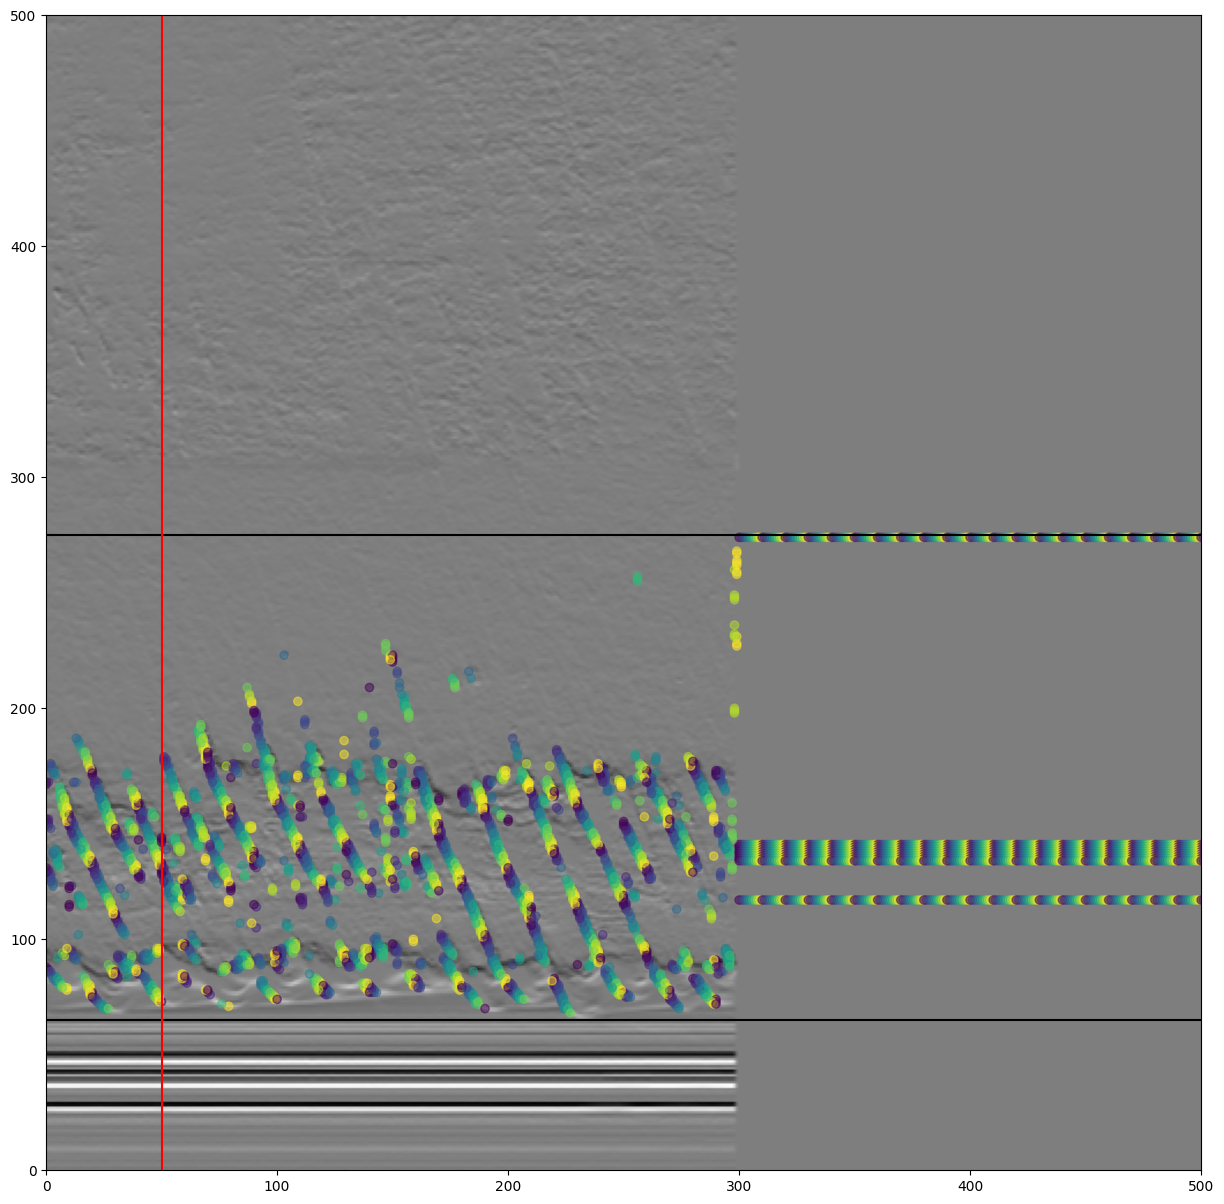

In [66]:
i = 10
plt.figure(figsize=(15, 15))
plt.imshow(sobel(timestack[:, i, :]).T)
c=10
plt.scatter(np.array([np.arange(timestack.shape[0])]*c), peaks[i][:c], c=[np.arange(c)]*timestack.shape[0], cmap='viridis', alpha=0.5)
plt.axhline(surf_zone_min, c='k')
plt.axhline(surf_zone_max, c='k')
plt.axvline(50, c='r')
plt.xlim(0, 500)
plt.ylim(0, 500)

In [24]:
# Trying to do peak finding instead of argmaxing so we get a better spatial distribution

In [25]:
# peaks = []

# for i in tqdm(range(0, timestack.shape[1])):
#     tp = []
#     for j in range(timestack.shape[0]):
#         surf_zone_min = 65
#         surf_zone_max = 275

#         pks= scipy.signal.find_peaks(sobel(timestack[j, i, surf_zone_min:surf_zone_max]))[0]
#         s = np.argsort(np.take(sobel(timestack[j, i, surf_zone_min:surf_zone_max]), pks))[::-1]
#         p = np.take(pks, s)
#         pks = np.zeros(20)
#         pks[:np.min([20, len(p)])] = p[:np.min([20, len(p)])]
#         tp.append(pks+surf_zone_min)
#     peaks.append(tp)

In [26]:
# i = 10
# c=10
# plt.figure(figsize=(15, 15))
# plt.imshow(sobel(timestack[:, i, :]).T)
# p = peaks[i]
# for j, p in enumerate(peaks[i]):
#     p=p[:c]
#     plt.scatter(np.array([j]*len(p)), p, c=[np.arange(len(p))], cmap='viridis', alpha=0.5)
# plt.axhline(surf_zone_min, c='k')
# plt.axhline(surf_zone_max, c='k')
# plt.axvline(50, c='r')
# plt.xlim(0, 500)
# plt.ylim(0, 500)

In [51]:
# DBSCAN to get rid of random points

# This needs some work. I feel like I should be able to get the full wave coming to shore in one piecem at least for some of these. And then maybe merge them w/ ransac?
c = 10
labels = []
filtered_peaks = []
for i in tqdm(range(len(peaks))): # Iterating over alongshore locations
    X = np.array([np.array([np.arange(timestack.shape[0])]*c).flatten(), peaks[i][:c].flatten()])
    clustering = DBSCAN(eps=4, min_samples=7).fit(X.T)
    l = clustering.labels_
    filtered_peaks.append(X[:, l>=0])
    labels.append(l[l>=0])

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_40445/353217501.py:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(*filtered_peaks[i][:, labels[i]==j], c=v[j])


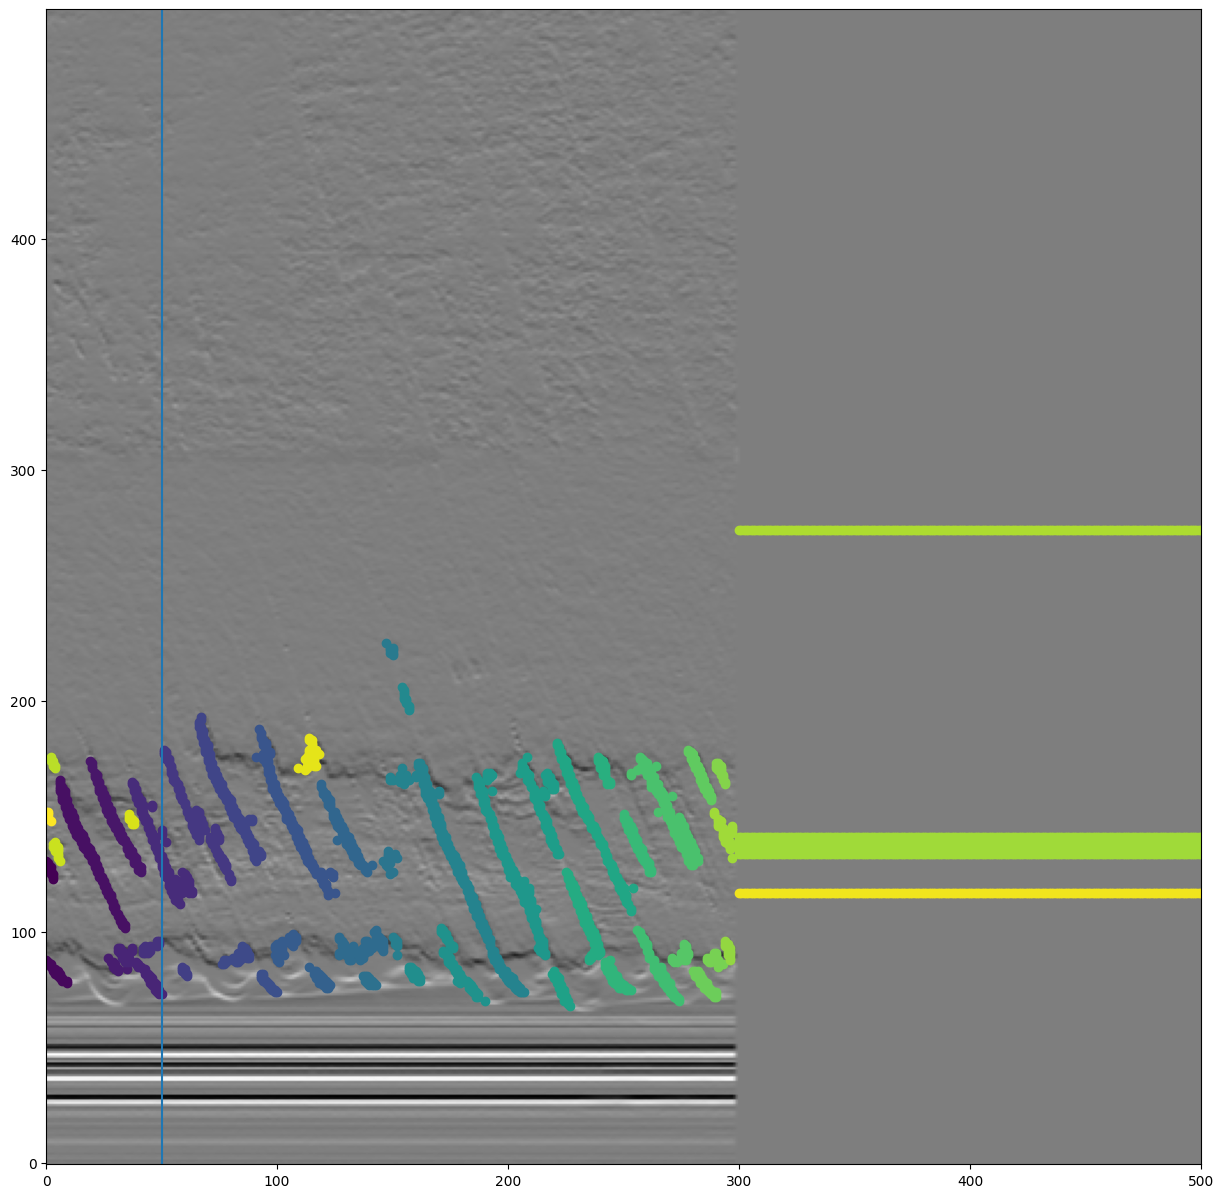

In [67]:
i = 10
plt.figure(figsize=(15, 15))
plt.imshow(sobel(timestack[:, i, :]).T)
N = 50
v= plt.get_cmap('viridis', N)(np.arange(N))
for j in range(N):
    plt.scatter(*filtered_peaks[i][:, labels[i]==j], c=v[j])
    # plt.scatter(*X[:, labels==1], c='g', alpha=0.5)
plt.xlim(0, 500)
plt.axvline(50)

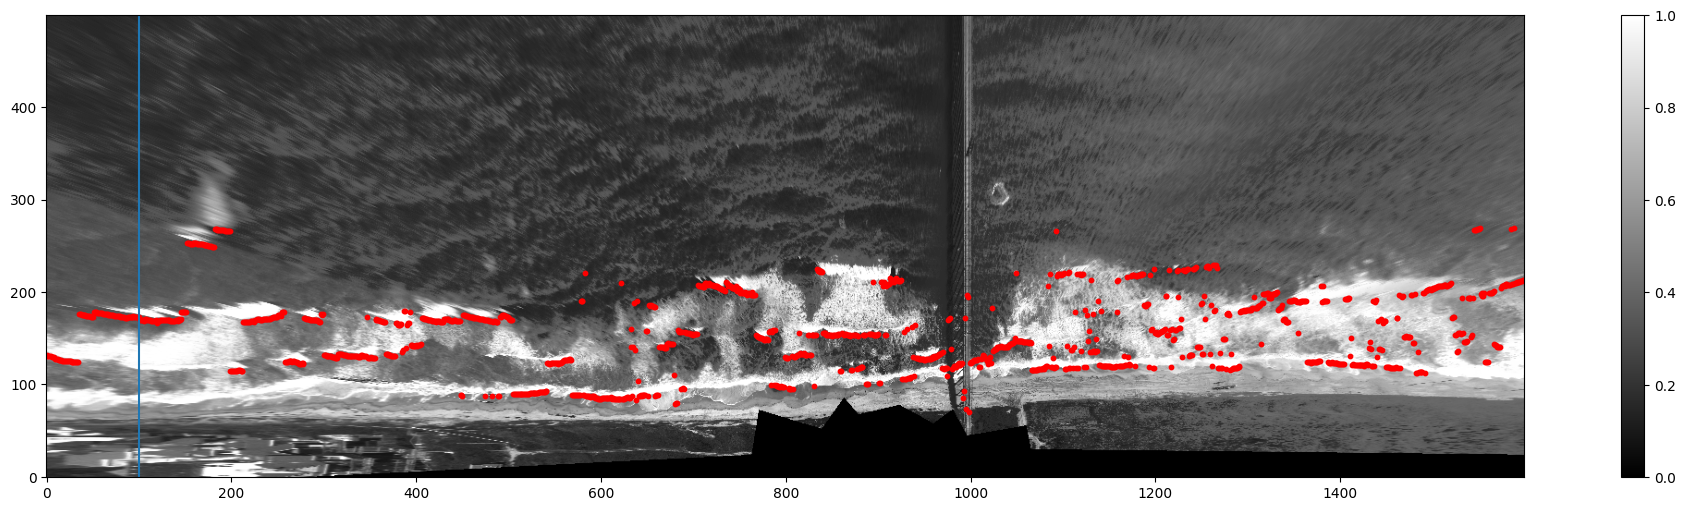

In [68]:
cap = cv2.VideoCapture(os.path.join(dir, file))
f = 51
for _ in range(f):
    _, frame = cap.read()
    frame = frame[..., 0]

c=1
plt.figure(figsize=(25,6))
plt.imshow(frame.T)
now = []
for i in range(len(peaks)):
    peak = filtered_peaks[i]
    if len(peak) != 0:
        peak = peak[:, peak[0, :]==f]
    if peak.size != 0:
        now_peaks = peak[..., :c]
        now.append(now_peaks[1, :])
        # plt.scatter(np.ones_like(now_peaks[1, :]) * i * 10, now_peaks[1, :], s=10, c=np.arange(np.min([now_peaks.shape[-1], c])), cmap='Reds')
        plt.scatter(np.ones_like(now_peaks[1, :]) * i * skip, now_peaks[1, :], s=10, c='r')
# plt.scatter([np.arange(0, 1600, 10)]*c, np.array(peaks)[:, :c, f], s=5, c='r')
plt.axvline(100)
plt.colorbar()

In [30]:
X = np.array((np.arange(1600), np.array(now).squeeze()))
clustering = DBSCAN(eps=4, min_samples=7).fit(X.T)
l = clustering.labels_
# filtered_peaks.append(X[:, l>=0])


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

(-0.5, 4030.975, -0.5, 499.5)

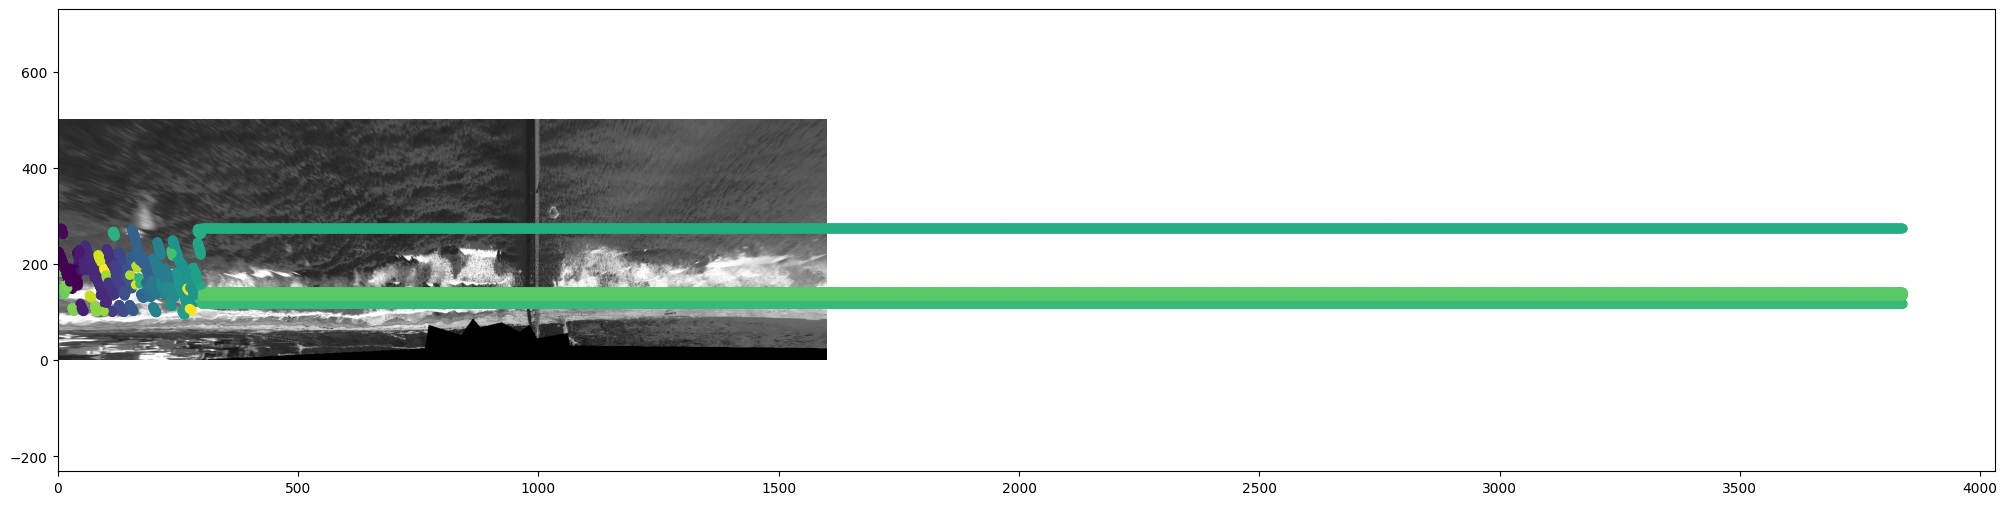

In [69]:
plt.figure(figsize=(25,6))
plt.imshow(frame.T)
plt.scatter(
    *X.T[l>0].T,
    c=l[l>0],
    cmap='viridis'
    )
plt.axis('equal')

In [71]:
peaks.shape

(1600, 210, 3840)

In [73]:
cap = cv2.VideoCapture(os.path.join(dir, file))

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS = 2
SECONDS = 100
NFRAMES = FPS * SECONDS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

out = cv2.VideoWriter('stingari2021_peak_tracking.avi',cv2.VideoWriter_fourcc('M','J','P','G'), FPS*20, (H,W))
for f in tqdm(range(NFRAMES)):
    _, frame = cap.read()
    # frame = frame[..., 0]

    c=3
    # plt.figure(figsize=(25,6))
    # plt.imshow(frame.T)
    for i in range(len(peaks)):
        peak = filtered_peaks[i]
        if len(peak) != 0:
            peak = peak[:, peak[0, :]==f]
        if peak.size != 0:
            now_peaks = peak[..., :c]
            # plt.scatter(np.ones_like(now_peaks[1, :]) * i * 10, now_peaks[1, :], s=10, c='r')#c=np.arange(np.min([now_peaks.shape[-1], c])), cmap='Reds')
            for ic, (iy, ix) in enumerate(zip(np.ones_like(now_peaks[1, :]) * i * skip, now_peaks[1, :])):
                cv2.circle(frame, (ix, iy), 3, (c-ic*50, c-ic*50, 255), -1)
            # frame[np.ones_like(now_peaks[1, :]) * i * 10, now_peaks[1, :]] = (255, 0, 0)
    out.write(np.flip(np.swapaxes(frame, 0, 1), 0))
    
cap.release()
out.release()
cv2.destroyAllWindows()
    # plt.scatter([np.arange(0, 1600, 10)]*c, np.array(peaks)[:, :c, f], s=5, c='r')
    # plt.axvline(100)
    # plt.colorbar()
!  ffmpeg -i stingari2021_peak_tracking.avi -t 5 -c:v libx264 stingari2021_peak_tracking_5s.mp4 -y

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:16<00:00, 12.17it/s]


ffmpeg version 7.0 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.3.9.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libopenvino -

: 

In [61]:
np.swapaxes(frame, 0, 1).shape

(500, 1600, 3)

In [134]:

breakers = []
for f in range(NFRAMES):
    _, frame = cap.read()
    # frame = frame[..., 0]

    c=10
    # plt.figure(figsize=(25,6))
    # plt.imshow(frame.T)
    for i in range(len(peaks)):
        peak = peaks[i]
        if len(peak) != 0:
            peak = peak[:, peak[0, :]==f]
        if peak.size != 0:
            now_peaks = peak[..., :c]
            breakers.append(np.array([np.ones_like(now_peaks[1, :]) * i * skip, now_peaks[1, :]]))
            # plt.scatter(np.ones_like(now_peaks[1, :]) * i * 10, now_peaks[1, :], s=10, c=np.arange(np.min([now_peaks.shape[-1], c])), cmap='Reds')
breakers = np.hstack(breakers)

count = np.zeros((1600, 500))
for b in breakers.T:
    count[b[0], b[1]]+=1



In [143]:
len(breakers.T)

1734571

(array([[485.,  15.,   0., ...,   0.,   0.,   0.],
        [487.,  11.,   2., ...,   0.,   0.,   0.],
        [486.,  14.,   0., ...,   0.,   0.,   0.],
        ...,
        [494.,   6.,   0., ...,   0.,   0.,   0.],
        [493.,   7.,   0., ...,   0.,   0.,   0.],
        [492.,   8.,   0., ...,   0.,   0.,   0.]]),
 array([0.        , 0.00666667, 0.01333333, 0.02      , 0.02666667,
        0.03333333, 0.04      , 0.04666667, 0.05333333, 0.06      ,
        0.06666667]),
 <a list of 1600 BarContainer objects>)

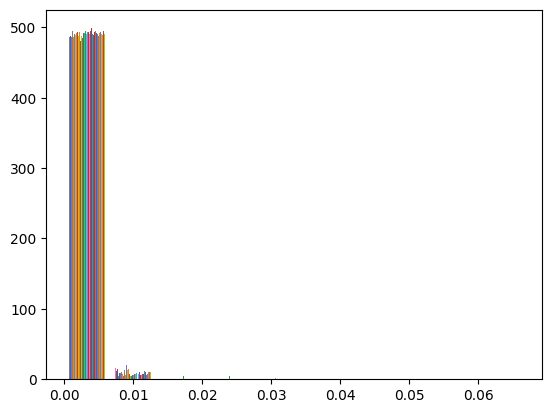

In [136]:
plt.hist(count.T/3840/(1/Tp))

1.0


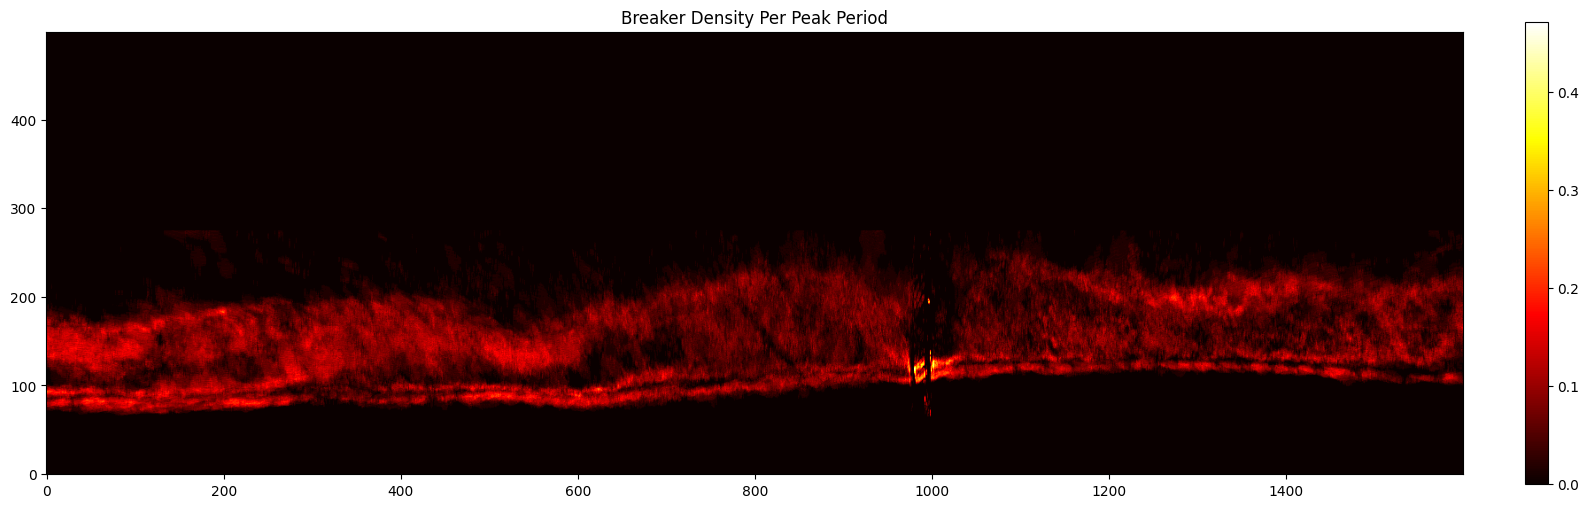

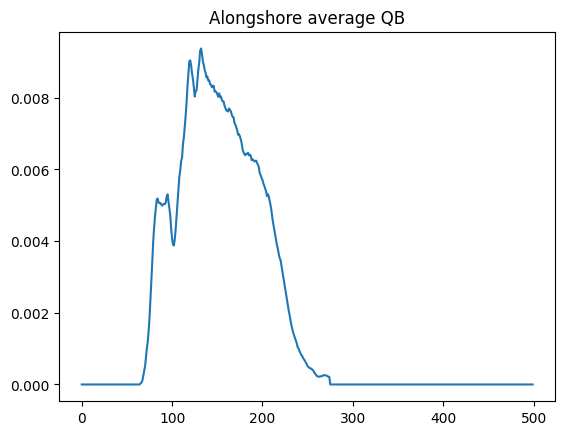

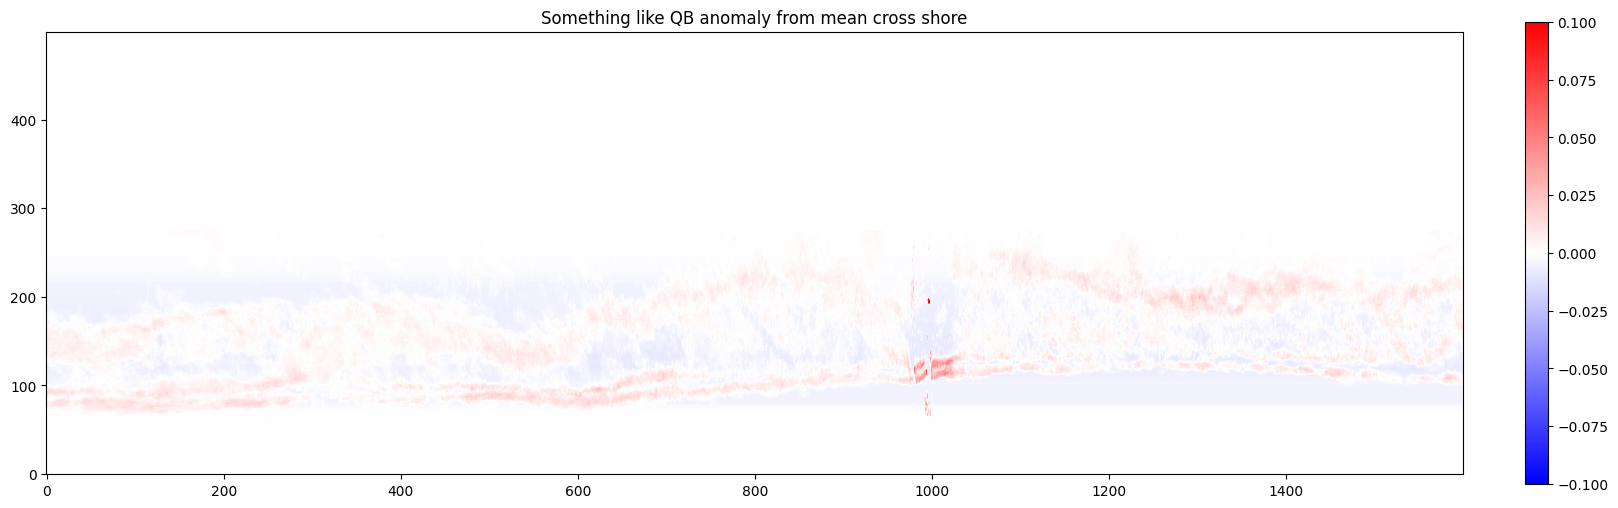

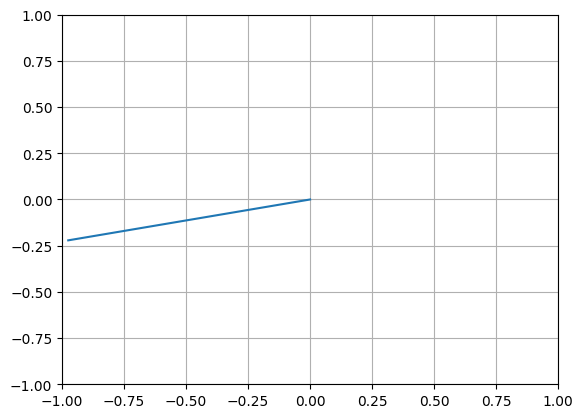

In [160]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(20, 10))
Tp = 7.631857
plt.title('Something like QB')
# plt.imshow(count.T/np.sum(count), cmap='hot') # Breaker Density
# plt.title('Breaker Density')
plt.imshow(count.T/(17*60/Tp), cmap='hot') # Breaker Density Per Peak Period
plt.title('Breaker Density Per Peak Period')
# plt.imshow(count.T/np.sum(count.T, axis=0), cmap='hot', vmin=0.005, vmax=0.04) # along-shore variation of normalized cross shore density
plt.colorbar(fraction=0.046, pad=0.04, shrink=0.6)
plt.figure()
plt.plot((count.T/np.sum(count.T, axis=0)).mean(axis=1))
plt.title('Alongshore average QB')
print((count.T/np.sum(count.T, axis=0)).mean(axis=1).sum())

plt.figure(figsize=(20, 10))
Tp = 8
plt.title('Something like QB anomaly from mean cross shore')
plt.imshow(count.T/np.sum(count.T, axis=0) - (count.T/np.sum(count.T, axis=0)).mean(axis=1)[:, np.newaxis], cmap='bwr', vmin=-0.1, vmax=0.1)
plt.colorbar(fraction=0.046, pad=0.04, shrink=0.6)

plt.figure()
FRF_OFFSET = 71.8535
plt.plot([0, np.sin(39.450039 + FRF_OFFSET)], [0, np.cos(39.450039 + FRF_OFFSET)])
plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.grid()

In [64]:
from KDEpy import FFTKDE

cap = cv2.VideoCapture(os.path.join(dir, file))
_, frame = cap.read()
frame = frame[..., :]

b=breakers.T
kde = FFTKDE(kernel='gaussian', norm=2)
grid, points = kde.fit(b).evaluate((3200, surf_zone_max - surf_zone_min))
x, y = np.unique(grid[:, 0]), np.unique(grid[:, 1])
points = points.reshape(3200, surf_zone_max - surf_zone_min)
points = points #/ np.sum(points, axis=1)[:, np.newaxis]
z = points.T

plt.figure(figsize=(20, 8))
plt.imshow(frame[..., 0].T)
contours = 300
# plt.contourf(x, y, z, contours, cmap="hot", alpha=0.75)
plt.pcolormesh(x, y, z, cmap="hot", alpha=0.75)

plt.ylim(0, 500)
plt.xlim(0, 1600)
plt.colorbar(label='Per Cross Shore Breaker Density')


NameError: name 'breakers' is not defined

In [252]:
cap = cv2.VideoCapture(os.path.join(dir, file))

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS = 2
SECONDS = 100
NFRAMES = FPS * SECONDS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

out = cv2.VideoWriter('stingari2021_peak_tracking.avi',cv2.VideoWriter_fourcc('M','J','P','G'), FPS*20, (W,H))
for f in range(NFRAMES):
    _, frame = cap.read()
    # frame = frame[..., 0]

    c=3
    # plt.figure(figsize=(25,6))
    # plt.imshow(frame.T)
    for i in range(len(peaks)):
        peak = peaks[i]
        if len(peak) != 0:
            peak = peak[:, peak[0, :]==f]
        if peak.size != 0:
            now_peaks = peak[..., :c]
        
           
            # plt.scatter(np.ones_like(now_peaks[1, :]) * i * 10, now_peaks[1, :], s=10, c='r')#c=np.arange(np.min([now_peaks.shape[-1], c])), cmap='Reds')
            for ic, (iy, ix) in enumerate(zip(np.ones_like(now_peaks[1, :]) * i * skip, now_peaks[1, :])):
                cv2.circle(frame, (ix, iy), 3, (c-ic*50, c-ic*50, 255), -1)
            # frame[np.ones_like(now_peaks[1, :]) * i * 10, now_peaks[1, :]] = (255, 0, 0)
    out.write(frame)
    
cap.release()
out.release()
cv2.destroyAllWindows()
    # plt.scatter([np.arange(0, 1600, 10)]*c, np.array(peaks)[:, :c, f], s=5, c='r')
    # plt.axvline(100)
    # plt.colorbar()
!  ffmpeg -i stingari2021_peak_tracking.avi -t 5 -c:v libx264 stingari2021_peak_tracking_5s.mp4 -y

ffmpeg version 7.0 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.3.9.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libopenvino -

In [ ]:
## Can you dbscan and group the waves into breakers? Can you then track them consistently through time?

In [352]:
c = 3
time_peaks = []
for f in range(NFRAMES):
    space_peaks = np.zeros((2, 3, len(peaks)))
    for i in range(len(peaks)):
        peak = peaks[i]
        if len(peak) != 0:
            peak = peak[:, peak[0, :]==f]
        if peak.size != 0:
            now_peaks = peak[..., :c]
                
            # plt.scatter(np.ones_like(now_peaks[1, :]) * i * 10, now_peaks[1, :], s=10, c='r')#c=np.arange(np.min([now_peaks.shape[-1], c])), cmap='Reds')
            space_peaks[0, :(min(c, len(now_peaks[1, :]))), i] = np.ones_like(now_peaks[1, :]) * i * skip
            space_peaks[1, :(min(c, len(now_peaks[1, :]))), i] = now_peaks[1, :]
            
        # space_peaks.append([])
    time_peaks.append(space_peaks)
len(time_peaks)

200

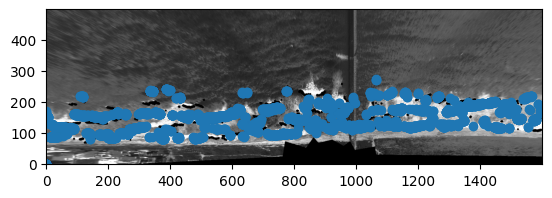

In [353]:
plt.imshow(frame[..., 0].T)
plt.scatter(*time_peaks[0])

In [119]:
i = 2
p = time_peaks[i].reshape(2, -1)
p = p[:, (p[0, :] > 0) & (p[1, :] > 0)].T
plt.scatter(*p.T)
clustering = DBSCAN(eps=3, min_samples=10).fit(p)
l = clustering.labels_
# time_peaks[i] = p[l>=0]
plt.imshow(frame)
plt.scatter(*p[l>=0].T, c=l[l>=0], cmap='jet')



NameError: name 'time_peaks' is not defined

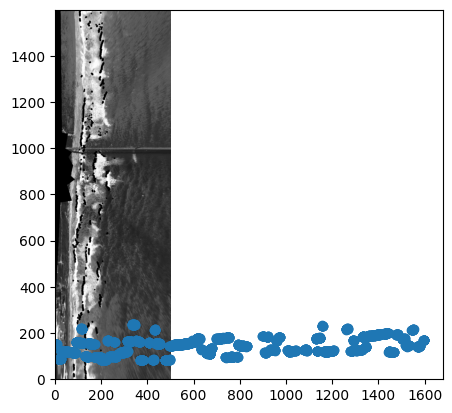

In [355]:
time_labels = []
for i in range(len(time_peaks)):
    p = time_peaks[i].reshape(2, -1)
    p = p[:, (p[0, :] > 0) & (p[1, :] > 0)].T
    # p=p[(p[:, 0] > 0) & (p[:, 1] > 0)]
    clustering = DBSCAN(eps=3, min_samples=10).fit(p)
    l = clustering.labels_
    time_peaks[i] = p[l>=0]
    time_labels.append(l[l>=0])
    
plt.imshow(frame[..., 0].T)
plt.scatter(*time_peaks[0].T)

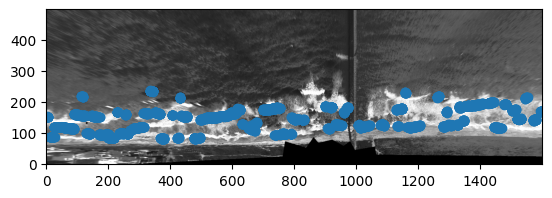

In [363]:
plt.imshow(frame[..., 0].T)
plt.scatter(*time_peaks[0].T)

In [373]:
cap = cv2.VideoCapture(os.path.join(dir, file))

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS = 2
SECONDS = 100
NFRAMES = FPS * SECONDS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

v= plt.get_cmap('viridis', 128)(np.arange(128))

out = cv2.VideoWriter('stingari2021_peak_tracking.avi',cv2.VideoWriter_fourcc('M','J','P','G'), FPS*20, (W,H))
for f in range(NFRAMES):
    _, frame = cap.read()
    # frame = frame[..., 0]

    for l, coord in zip(time_labels[f], time_peaks[f].astype(int)):
        cv2.circle(frame, (coord[1], coord[0]), 3, v[l][:3], -1)
    out.write(frame)
    
cap.release()
out.release()
cv2.destroyAllWindows()
!  ffmpeg -i stingari2021_peak_tracking.avi -t 5 -c:v libx264 stingari2021_peak_tracking_5s.mp4 -y

ffmpeg version 7.0 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.3.9.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libopenvino -

In [ ]:
## Can you identify the non-breaking waves? I think this is either going to be super hard or there's some easy signal processing thing. 
# The gradients are weak, but if we assume constant velocity we can just draw lines from the breakers (assuming we get all the breakers)

(0.0, 500.0)

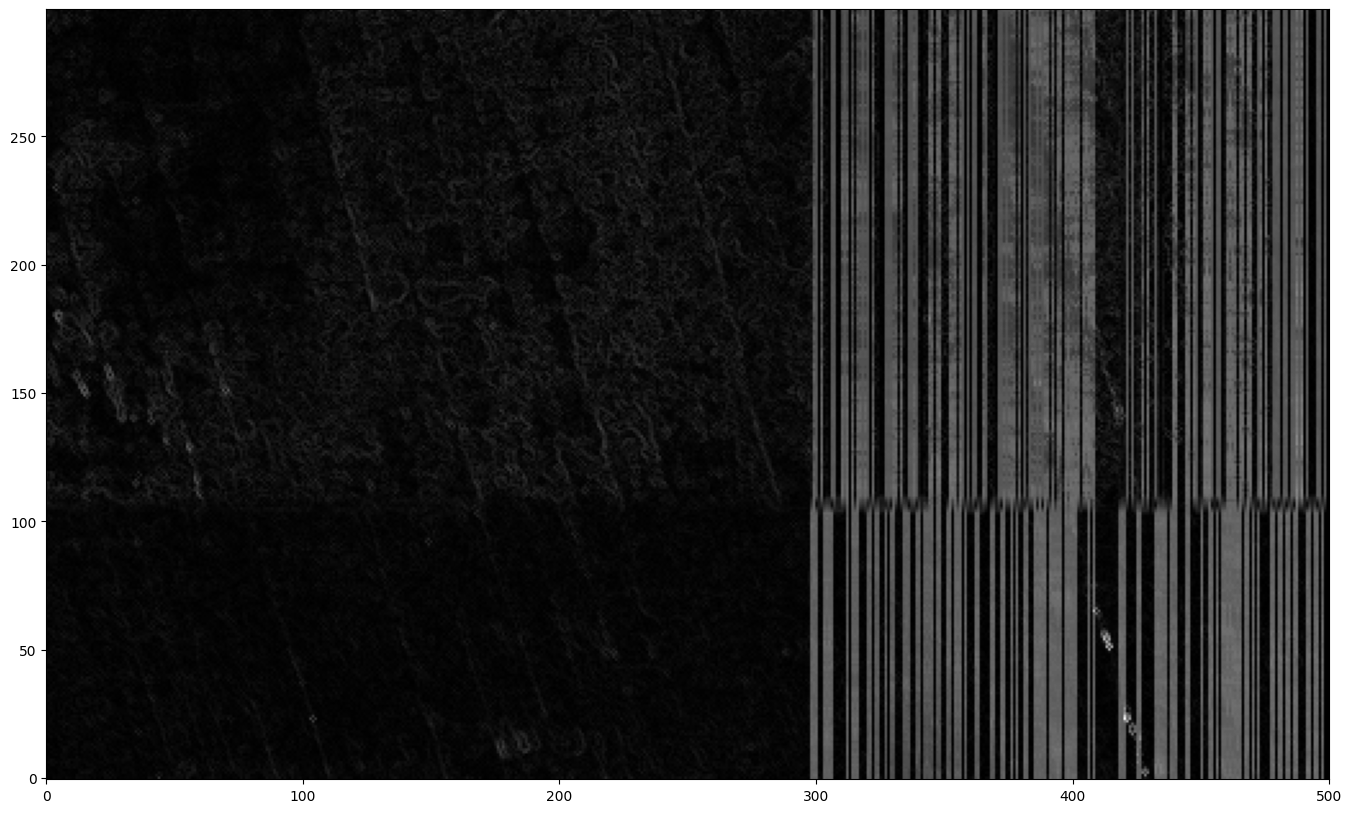

In [159]:
plt.figure(figsize=(20, 10))
xmax=500
plt.imshow(np.linalg.norm(np.array(np.gradient(timestack[:xmax, 10, 200:].T)), axis=0))
# plt.scatter(np.arange(xmax), peaks[:xmax, 10, :][:, 0])
plt.xlim(0 ,xmax)

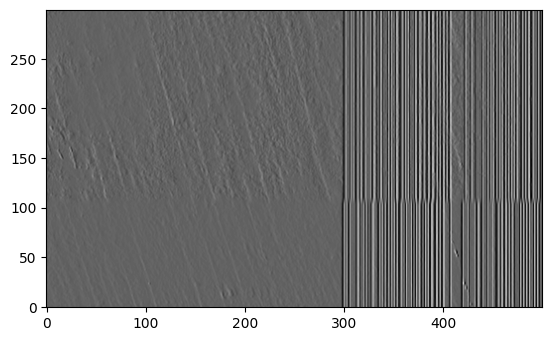

In [161]:
plt.imshow(sobel(timestack[:xmax, 10, 200:].T))